# Reproducing the numerical examples from `152.pdf`

This notebook realizes all numerical examples in Section 9.3 of the paper:

- Figure 1: Example 9.1, `q(x) = x exp(-x^2)`, at `t = 0, 0.08, 0.16`.
- Figure 2: Example 9.2, the reflectionless soliton with `c = pi`, at `t = 0, 0.5, 1`.
- Figure 3: Example 9.3 initial profile.
- Figure 4: Example 9.3 evolution at `t = 0, 0.015, 0.03`.

The companion script `paper_examples_kdv.jl` contains the implementation. It uses a Fourier ETDRK4 KdV time stepper for the two general Cauchy problems and the exact solitary-wave formula reported in the paper for Example 9.2. Running the notebook saves PNG and PDF versions of the figures under `figures/`.

In [282]:
include("paper_examples_kdv.jl")

## Generate all figures

This call creates the four paper-style figures and writes a validation summary.

In [283]:
results = run_all_examples(outdir="figures")
results.summary_path

"figures/validation_summary.txt"

## Validation summary

In [284]:
println(read(results.summary_path, String))

Validation summary for 152.pdf numerical examples

Figure 1 / Example 9.1
  Initial data: q(x) = x exp(-x^2)
  Paper time slices: t = 0, 0.08, 0.16
  Paper reports lambda1 approx -0.0138384593995, alpha- approx 0.2055954681199, alpha+ approx 0.0416040800785.
  t=0.00000 mass=-6.938893903907e-17 mass_drift= 0.000e+00 L2= 3.133285343289e-01 L2_drift= 0.000e+00
  t=0.28000 mass=-1.040834085586e-16 mass_drift= 3.469e-17 L2= 3.133285343289e-01 L2_drift= 2.942e-15
  t=0.40000 mass=-1.387778780781e-16 mass_drift= 6.939e-17 L2= 3.133285343289e-01 L2_drift= 1.332e-15
  t=0.50000 mass= 0.000000000000e+00 mass_drift= 6.939e-17 L2= 3.133285343289e-01 L2_drift= 6.106e-16
  t=0.60000 mass=-6.938893903907e-17 mass_drift= 0.000e+00 L2= 3.133285343289e-01 L2_drift= 0.000e+00

Figure 2 / Example 9.2
  Initial data: q(x) = -c/2 sech^2(sqrt(c)x/2), c = pi
  Exact lambda1 = -pi/4 = -0.78539816339745
  Exact alpha+ = alpha- = sqrt(pi) = 1.77245385090552
  Paper time slices: t = 0, 0.5, 1
  Figure generated 

## Display saved figures

In [285]:
# display("image/png", read("figures/figure1_example91.png"))

In [286]:
# display("image/png", read("figures/figure2_example92.png"))

In [287]:
# display("image/png", read("figures/figure3_example93_initial.png"))

In [288]:
# display("image/png", read("figures/figure4_example93.png"))

## Custom initial data, animation, and wave field

Choose an initial profile, solve the KdV evolution, show the animation inline, and plot the 3D field `(x,t,u(x,t))`.

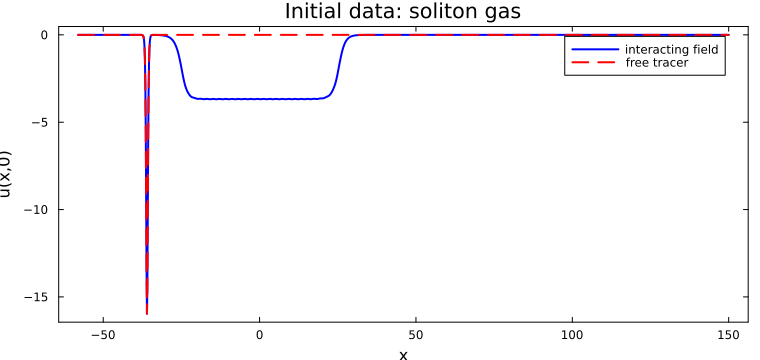

In [289]:
mkpath("figures")

# Switch this between :paper91, :semiclassical, :multi_soliton, :soliton_gas, and :custom.
# The :semiclassical preset is a smooth-well initial profile under the current KdV scaling.
initial_kind = :soliton_gas
show_tracer = initial_kind == :soliton_gas

evolution_xmin, evolution_xmax = -60.0, 160.0
evolution_n = 2048*4
evolution_dt = 2e-4
# With the multi-soliton preset, interactions occur around t = 4 and t = 5.
evolution_save_every = 100
evolution_frame_count = 121
evolution_xplot = collect(range(-58.0, 150.0; length=1600))

custom_initial(x) = 0.65 * sin(2.0x) * exp(-x^2 / 24)
large_soliton = (c=32.0, x0=-36.0)

free_soliton_profile(x, t, soliton=large_soliton) =
    -soliton.c / 2 * sech(sqrt(soliton.c) * (x - soliton.x0 - soliton.c * t) / 2)^2

function kdv_initial_data(x; kind=initial_kind)
    if kind == :paper91
        return x * exp(-x^2)
    elseif kind == :semiclassical
        return -1.1 * sech(x / 5)^2
    elseif kind == :multi_soliton
        solitons = ((c=3.6, x0=-7.0), (c=2.1, x0=-1.0), (c=0.9, x0=5.0))
        return sum(-s.c / 2 * sech(sqrt(s.c) * (x - s.x0) / 2)^2 for s in solitons)
    elseif kind == :soliton_gas
        centers = collect(range(-25.0, 25.0; length=100))
        speeds = @. 0.4 + 1.0 * (0.5 + 0.5 * sin(3.123* centers + 0.7))
        gas = sum(-c / 2 * sech(sqrt(c) * (x - x0) / 2)^2 for (c, x0) in zip(speeds, centers))
        large = free_soliton_profile(x, 0.0)
        return gas + large
    elseif kind == :custom
        return custom_initial(x)
    else
        error("Unknown initial_kind: $kind")
    end
end

evolution_label = replace(string(initial_kind), "_" => " ")
evolution_case = replace(string(initial_kind), "_" => "-")
evolution_times = evolution_dt * evolution_save_every .* collect(0:evolution_frame_count-1)
evolution_xgrid = collect(range(evolution_xmin, evolution_xmax; length=evolution_n + 1))[1:end-1]
evolution_q0 = [kdv_initial_data(x) for x in evolution_xgrid]
evolution_q0_plot = interpolate_periodic(evolution_xgrid, evolution_q0, evolution_xplot)

initial_plot = plot(evolution_xplot, evolution_q0_plot;
     color=:blue,
     linewidth=2,
     label="interacting field",
     legend=show_tracer ? :topright : false,
     xlabel="x",
     ylabel="u(x,0)",
     title="Initial data: $(evolution_label)",
     framestyle=:box,
     grid=false,
     size=(760, 360))

if show_tracer
    plot!(initial_plot, evolution_xplot, free_soliton_profile.(evolution_xplot, 0.0);
          color=:red,
          linestyle=:dash,
          linewidth=2,
          label="free tracer")
end

initial_plot

In [290]:
evolution_solution = solve_kdv_etdrk4(evolution_q0, evolution_xgrid, evolution_times; dt=evolution_dt)

evolution_wavefield = hcat(
    [interpolate_periodic(evolution_xgrid, evolution_solution[t], evolution_xplot)
     for t in evolution_times]...
)

evolution_tracer_wavefield = show_tracer ? hcat(
    [free_soliton_profile.(evolution_xplot, t) for t in evolution_times]...
) : Array{Float64}(undef, length(evolution_xplot), 0)

(profile=initial_kind,
 size=size(evolution_wavefield),
 tracer=show_tracer ? large_soliton : nothing,
 tspan=(first(evolution_times), last(evolution_times)))

(profile = :soliton_gas, size = (1600, 121), tracer = (c = 32.0, x0 = -36.0), tspan = (0.0, 2.4))

Plots.AnimatedGif("/Users/fudong/Desktop/ResearchProjects/NumIST/figures/kdv_soliton-gas_time_evolution.gif")
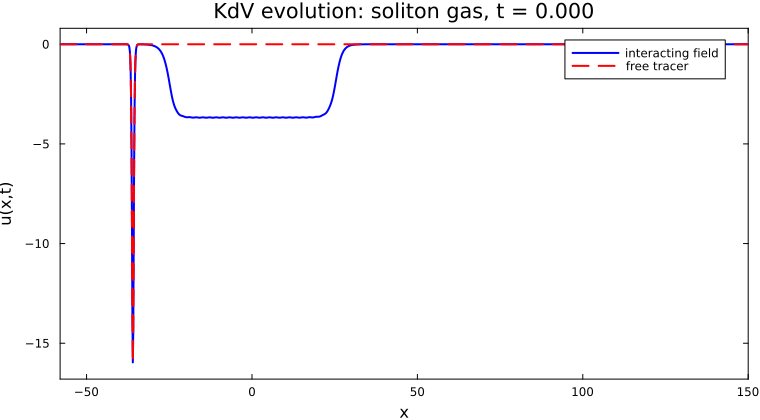

┌ Info: Saved animation to /Users/fudong/Desktop/ResearchProjects/NumIST/figures/kdv_soliton-gas_time_evolution.gif
└ @ Plots /Users/fudong/.julia/packages/Plots/xC48f/src/animation.jl:156


"figures/kdv_soliton-gas_time_evolution.gif"

In [291]:
evolution_ylims = show_tracer ?
    extrema(vcat(vec(evolution_wavefield), vec(evolution_tracer_wavefield))) :
    extrema(evolution_wavefield)
evolution_pad = 0.05 * max(evolution_ylims[2] - evolution_ylims[1], eps(Float64))

evolution_anim = @animate for (j, t) in enumerate(evolution_times)
    frame = plot(evolution_xplot, evolution_wavefield[:, j];
         color=:blue,
         linewidth=2,
         label="interacting field",
         legend=show_tracer ? :topright : false,
         xlabel="x",
         ylabel="u(x,t)",
         xlims=(first(evolution_xplot), last(evolution_xplot)),
         ylims=(evolution_ylims[1] - evolution_pad, evolution_ylims[2] + evolution_pad),
         title=@sprintf("KdV evolution: %s, t = %.3f", evolution_label, t),
         framestyle=:box,
         grid=false,
         size=(760, 420))
    if show_tracer
        plot!(frame, evolution_xplot, evolution_tracer_wavefield[:, j];
              color=:red,
              linestyle=:dash,
              linewidth=2,
              label="free tracer")
    end
    frame
end

animation_path = joinpath("figures", "kdv_$(evolution_case)_time_evolution.gif")
# `gif` returns a Plots.AnimatedGif; Jupyter can render that object inline.
animation_gif = gif(evolution_anim, animation_path; fps=20)
display(animation_gif)
animation_path

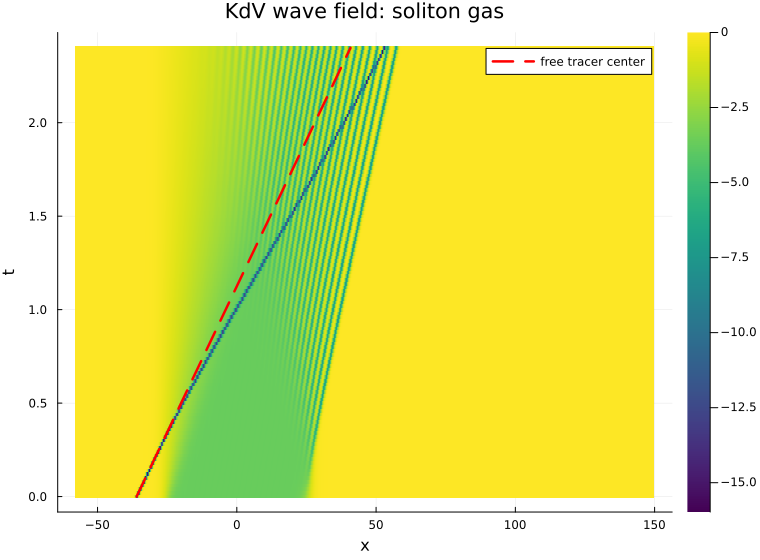

"figures/kdv_soliton-gas_wave_field_surface.png"

In [292]:
wave_surface = heatmap(evolution_xplot, evolution_times, permutedims(evolution_wavefield);
                       xlabel="x",
                       ylabel="t",
                       zlabel="u(x,t)",
                       title="KdV wave field: $(evolution_label)",
                       camera=(45, 28),
                       color=:viridis,
                       linewidth=0,
                       legend=show_tracer ? :topright : false,
                       colorbar=true,
                       size=(760, 560))

if show_tracer
    tracer_center_x = large_soliton.x0 .+ large_soliton.c .* evolution_times
    plot!(wave_surface, tracer_center_x, evolution_times;
          color=:red,
          linestyle=:dash,
          linewidth=2.5,
          label="free tracer center")
end

surface_path = joinpath("figures", "kdv_$(evolution_case)_wave_field_surface.png")
savefig(wave_surface, surface_path)
display(wave_surface)
surface_path

## Files written

In [293]:
sort(readdir("figures"))

15-element Vector{String}:
 "example91_time_evolution.gif"
 "example91_wave_field_surface.png"
 "figure1_example91.pdf"
 "figure1_example91.png"
 "figure2_example92.pdf"
 "figure2_example92.png"
 "figure3_example93_initial.pdf"
 "figure3_example93_initial.png"
 "figure4_example93.pdf"
 "figure4_example93.png"
 "kdv_multi-soliton_time_evolution.gif"
 "kdv_multi-soliton_wave_field_surface.png"
 "kdv_soliton-gas_time_evolution.gif"
 "kdv_soliton-gas_wave_field_surface.png"
 "validation_summary.txt"